# Inkingi Shield — ML Fraud Detection Model

**Author:** Armand Kayiranga  
**Project:** Inkingi Shield — Real-Time Fraud Detection for Rwanda's Financial Ecosystem  
**Track:** BSc Software Engineering Capstone · African Leadership University · 2026

---

This notebook documents the full machine learning pipeline for the Inkingi Shield fraud detection system.
The trained model is deployed as a **Gradio API on Hugging Face Spaces** and called in real-time by
the FastAPI backend serving the analyst dashboard.

**Dataset:** PaySim — a synthetic simulation of mobile money transactions modeled on real financial data  
**Model:** Random Forest Classifier (scikit-learn)  
**Deployment:** `huggingface/model.pkl` → Hugging Face Spaces → FastAPI backend → React dashboard

### Pipeline Overview
1. Load and explore the PaySim dataset (6.3M transactions)
2. Exploratory Data Analysis — fraud patterns, transaction types, amounts
3. Feature Engineering — encode transaction type, derive balance features
4. Model Training — Random Forest with class weighting for imbalanced data
5. Model Evaluation — accuracy, precision, recall, F1, ROC-AUC
6. Feature Importance — explainability for fraud analysts
7. Save model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Dataset

The **PaySim** dataset simulates 6.3 million mobile money transactions over 30 days.
It was generated from real transaction logs and is widely used to benchmark fraud detection models
in the context of mobile money — the dominant payment channel in East Africa.

In [2]:
DATA_PATH = '../backend/data/PS_20174392719_1491204439457_log.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print('Dataset Info:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Dataset Info:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64



Memory usage: 1.52 GB


## 2. Exploratory Data Analysis

Key questions:
- How imbalanced is the dataset? (fraud is rare by nature)
- Which transaction types carry the most fraud?
- What are the typical amounts in fraudulent transactions?
- How does balance behavior differ between fraud and legitimate?

In [4]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate = df['isFraud'].mean() * 100

print('Class Distribution:')
print(fraud_counts)
print(f'\nFraud rate: {fraud_rate:.4f}%')
print(f'Legitimate transactions: {fraud_counts[0]:,}')
print(f'Fraudulent transactions:  {fraud_counts[1]:,}')

Class Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%
Legitimate transactions: 6,354,407
Fraudulent transactions:  8,213


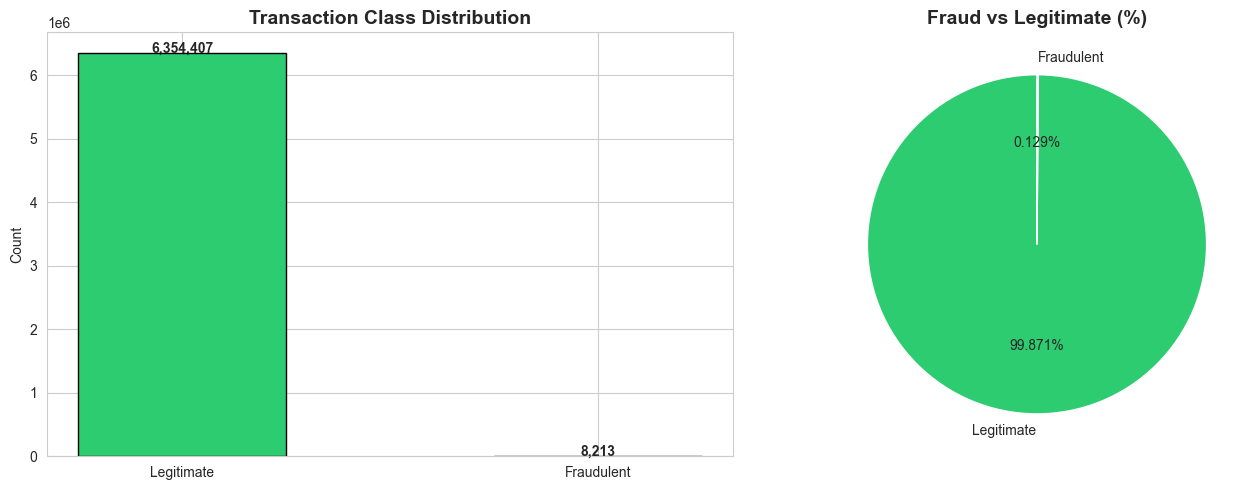

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.3f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Fraud by Transaction Type:
          fraud_count    total  fraud_rate_%
type                                        
TRANSFER         4097   532909      0.768799
CASH_OUT         4116  2237500      0.183955
CASH_IN             0  1399284      0.000000
DEBIT               0    41432      0.000000
PAYMENT             0  2151495      0.000000


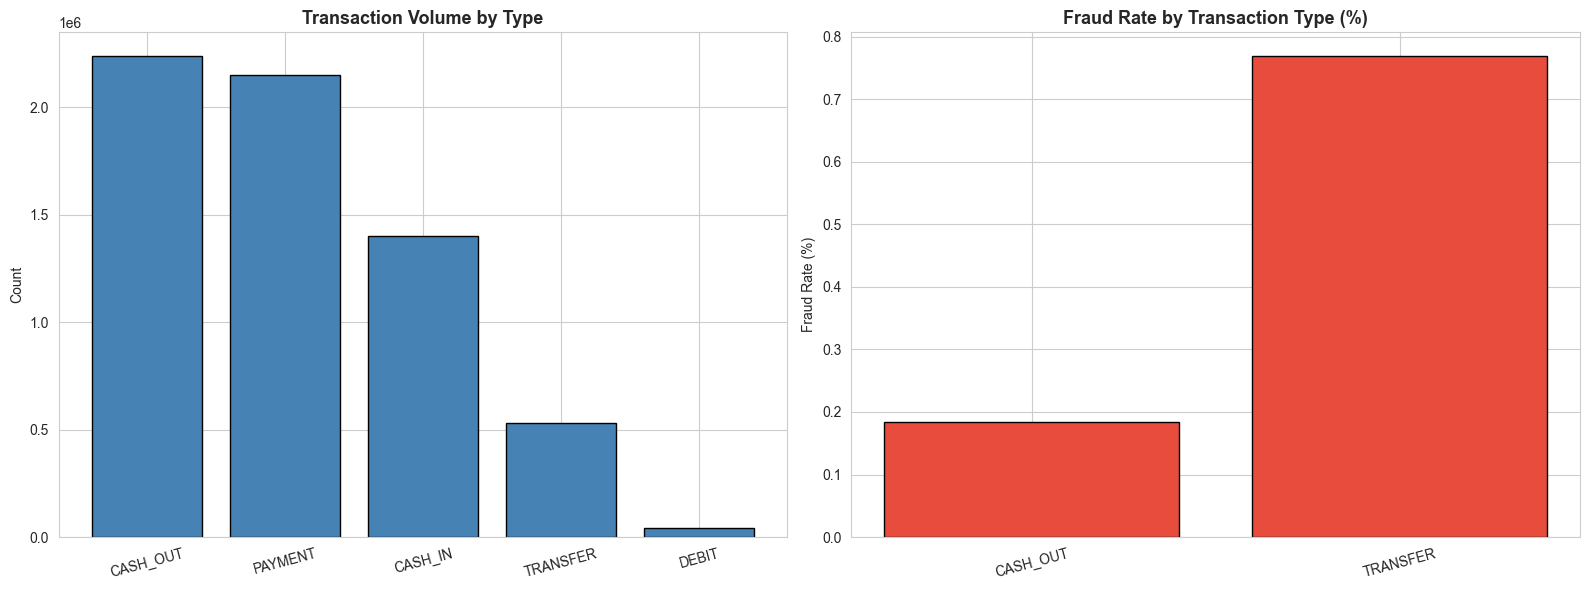


Key finding: Fraud occurs ONLY in CASH_OUT and TRANSFER transactions.


In [6]:
# Fraud by transaction type
type_fraud = df.groupby('type')['isFraud'].agg(['sum', 'count'])
type_fraud['fraud_rate'] = (type_fraud['sum'] / type_fraud['count']) * 100
type_fraud.columns = ['fraud_count', 'total', 'fraud_rate_%']

print('Fraud by Transaction Type:')
print(type_fraud.sort_values('fraud_rate_%', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transaction volume by type
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Volume by Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Fraud rate by type
fraud_types = type_fraud[type_fraud['fraud_count'] > 0]
axes[1].bar(fraud_types.index, fraud_types['fraud_rate_%'],
            color='#e74c3c', edgecolor='black')
axes[1].set_title('Fraud Rate by Transaction Type (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print('\nKey finding: Fraud occurs ONLY in CASH_OUT and TRANSFER transactions.')

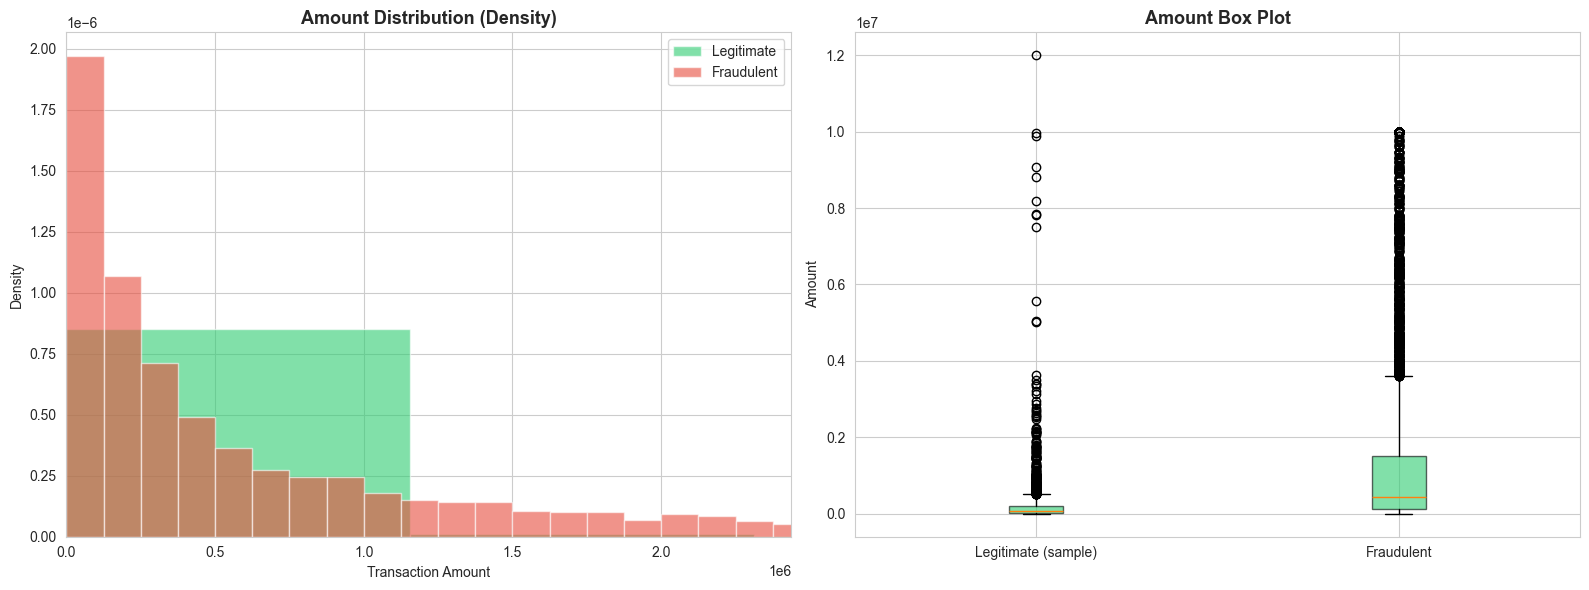

Fraudulent transaction amount stats:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


In [7]:
# Amount distribution — fraud vs legitimate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

legit = df[df['isFraud'] == 0]['amount']
fraud = df[df['isFraud'] == 1]['amount']

axes[0].hist(legit, bins=80, alpha=0.6, color='#2ecc71',
             label='Legitimate', density=True)
axes[0].hist(fraud, bins=80, alpha=0.6, color='#e74c3c',
             label='Fraudulent', density=True)
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (Density)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, df['amount'].quantile(0.995))

# Box plot
axes[1].boxplot([legit.sample(5000, random_state=42), fraud],
                labels=['Legitimate (sample)', 'Fraudulent'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.6))
fraud_box = axes[1].findobj(plt.Line2D)
axes[1].set_title('Amount Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

print(f'Fraudulent transaction amount stats:')
print(fraud.describe())

Fraudulent transactions that completely drain the sender account:
8,012 out of 8,213 (97.6%)


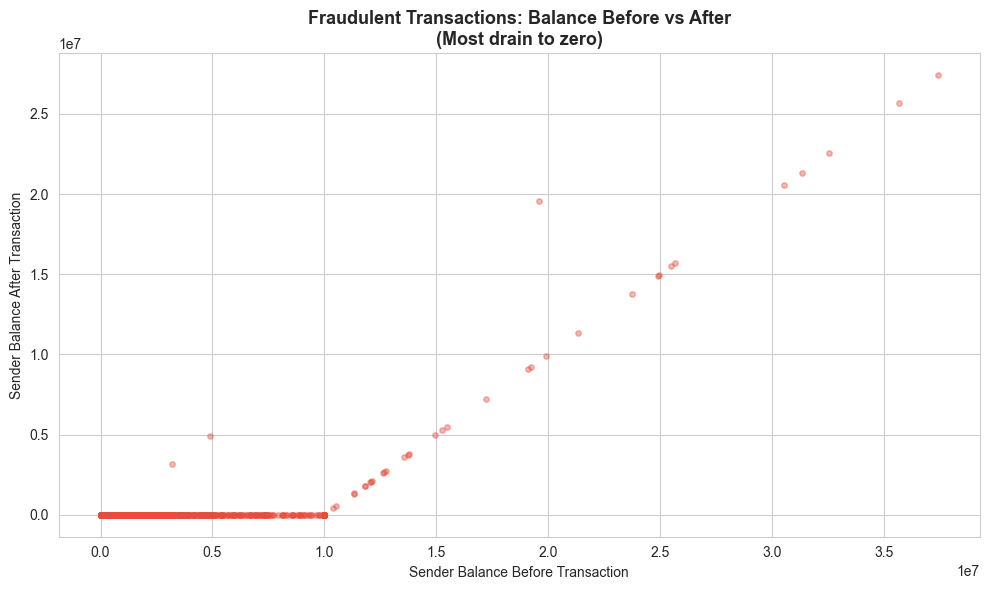

In [8]:
# Balance drain pattern — key fraud indicator
fraud_only = df[df['isFraud'] == 1].copy()

balance_drain = (fraud_only['oldbalanceOrg'] > 0) & (fraud_only['newbalanceOrig'] == 0)
print(f'Fraudulent transactions that completely drain the sender account:')
print(f'{balance_drain.sum():,} out of {len(fraud_only):,} ({balance_drain.mean()*100:.1f}%)')

# Scatter: old vs new balance for fraud
sample = fraud_only.sample(min(2000, len(fraud_only)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['oldbalanceOrg'], sample['newbalanceOrig'],
            alpha=0.4, color='#e74c3c', s=15)
plt.xlabel('Sender Balance Before Transaction')
plt.ylabel('Sender Balance After Transaction')
plt.title('Fraudulent Transactions: Balance Before vs After\n(Most drain to zero)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

The production model uses 6 features derived from the raw PaySim columns:

| Feature | Source | Rationale |
|---------|--------|----------|
| `amount` | raw | Transaction value — large transfers are high risk |
| `type_enc` | encoded `type` | Only CASH_OUT (0) and TRANSFER (1) show fraud |
| `old_balance` | `oldbalanceOrg` | Account balance before — context for relative amount |
| `new_balance` | `newbalanceOrig` | Balance after — zero = account drained |
| `balance_diff` | `old - new` | Direct measure of balance loss |
| `amount_ratio` | `amount / (old + 1)` | Relative size of transaction vs available balance |

In [9]:
TYPE_MAP = {'CASH_OUT': 0, 'TRANSFER': 1, 'CASH_IN': 2, 'PAYMENT': 3, 'DEBIT': 4}

df['type_enc']      = df['type'].map(TYPE_MAP)
df['balance_diff']  = df['oldbalanceOrg'] - df['newbalanceOrig']
df['amount_ratio']  = df['amount'] / (df['oldbalanceOrg'] + 1.0)

FEATURES = ['amount', 'type_enc', 'oldbalanceOrg', 'newbalanceOrig',
            'balance_diff', 'amount_ratio']
TARGET   = 'isFraud'

print('Engineered features:')
print(df[FEATURES + [TARGET]].describe())
print(f'\nFeature set: {FEATURES}')

Engineered features:


             amount      type_enc  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   1.798619e+05  1.564087e+00   8.338831e+05    8.551137e+05   
std    6.038582e+05  1.290187e+00   2.888243e+06    2.924049e+06   
min    0.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.338957e+04  0.000000e+00   0.000000e+00    0.000000e+00   
50%    7.487194e+04  2.000000e+00   1.420800e+04    0.000000e+00   
75%    2.087215e+05  3.000000e+00   1.073152e+05    1.442584e+05   
max    9.244552e+07  4.000000e+00   5.958504e+07    4.958504e+07   

       balance_diff  amount_ratio       isFraud  
count  6.362620e+06  6.362620e+06  6.362620e+06  
mean  -2.123056e+04  7.067448e+04  1.290820e-03  
std    1.466433e+05  5.084243e+05  3.590480e-02  
min   -1.915268e+06  0.000000e+00  0.000000e+00  
25%    0.000000e+00  2.344011e-01  0.000000e+00  
50%    0.000000e+00  6.453832e+00  0.000000e+00  
75%    1.015044e+04  1.228776e+04  0.

## 4. Prepare Training Data

The full dataset has 6.3M rows. We use a **stratified sample of 500K rows** for training
to keep training time manageable while preserving the fraud/legitimate ratio.
The model is evaluated on a held-out 20% test set.

In [10]:
SAMPLE_SIZE = 500_000
RANDOM_STATE = 42

# Stratified sample to preserve fraud rate
df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE, weights=None)
# Ensure we include enough fraud examples
fraud_df  = df[df['isFraud'] == 1]
legit_df  = df[df['isFraud'] == 0].sample(n=SAMPLE_SIZE - len(fraud_df),
                                           random_state=RANDOM_STATE)
df_sample = pd.concat([fraud_df, legit_df]).sample(frac=1, random_state=RANDOM_STATE)

X = df_sample[FEATURES]
y = df_sample[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')
print(f'\nFraud in training: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Fraud in test:     {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

Training set:  400,000 rows
Test set:      100,000 rows

Fraud in training: 6,570 (1.64%)
Fraud in test:     1,643 (1.64%)


## 5. Train the Model

We use a **Random Forest Classifier** — an ensemble of decision trees that:
- Handles the highly imbalanced dataset using `class_weight='balanced'`
- Is robust to outliers and non-linear feature relationships
- Provides native feature importance scores for explainability
- Generalises well without extensive hyperparameter tuning

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Training Random Forest...')
model.fit(X_train, y_train)
print('Training complete.')

Training Random Forest...


Training complete.


## 6. Model Evaluation

In [12]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print('=' * 55)
print('  INKINGI SHIELD — RANDOM FOREST PERFORMANCE')
print('=' * 55)
print(f'  Accuracy:   {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision:  {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall:     {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score:   {f1:.4f}')
print(f'  ROC-AUC:    {roc_auc:.4f}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraudulent']))

  INKINGI SHIELD — RANDOM FOREST PERFORMANCE
  Accuracy:   1.0000  (100.00%)
  Precision:  0.9994  (99.94%)
  Recall:     0.9982  (99.82%)
  F1-Score:   0.9988
  ROC-AUC:    0.9999

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     98357
  Fraudulent       1.00      1.00      1.00      1643

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



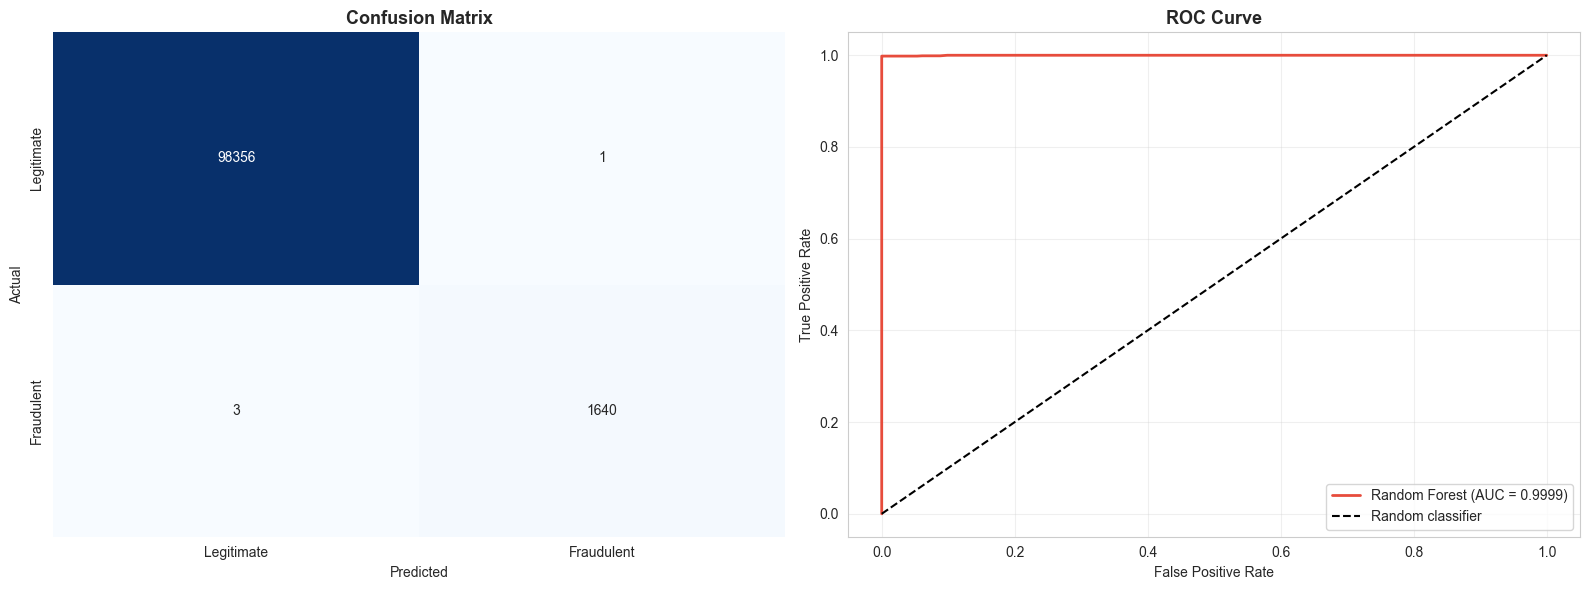

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, lw=2, color='#e74c3c',
             label=f'Random Forest (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance

The Random Forest gives us native feature importance scores.
These are surfaced directly in the analyst dashboard under each fraud alert
so analysts understand **why** the model flagged a transaction.

Feature Importances:
  amount_ratio    ███████████████  31.0%
  balance_diff    ███████████████  30.9%
  type_enc        ███████  15.9%
  new_balance     █████  11.7%
  old_balance     ███  6.3%
  amount          ██  4.2%


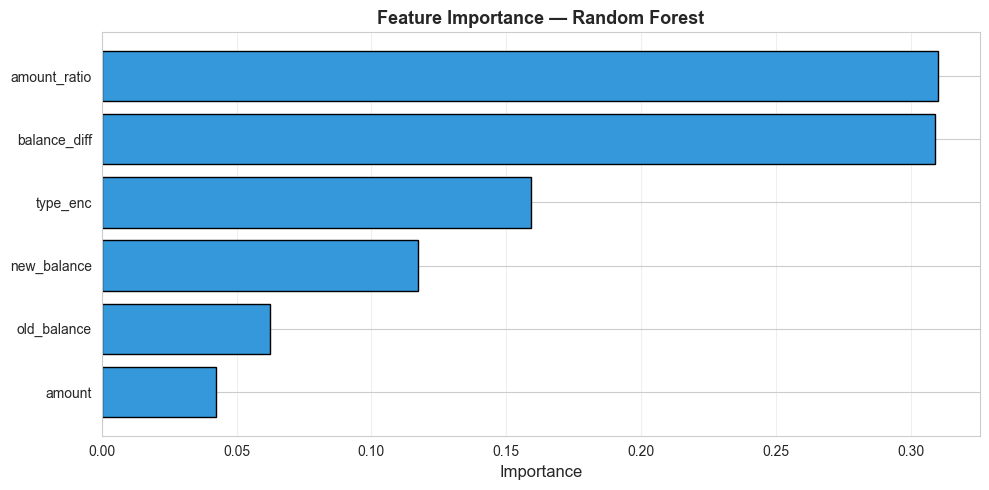

In [14]:
FEATURE_NAMES = ['amount', 'type_enc', 'old_balance', 'new_balance',
                 'balance_diff', 'amount_ratio']

importances = model.feature_importances_
feat_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Feature Importances:')
for _, row in feat_df.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<15} {bar}  {row['importance']*100:.1f}%")

plt.figure(figsize=(10, 5))
plt.barh(feat_df['feature'], feat_df['importance'],
         color='#3498db', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Live Prediction Test

Verify the model produces sensible outputs for the same example inputs
used in the Hugging Face Spaces Gradio interface.

In [15]:
def predict_transaction(amount, tx_type, old_balance, new_balance):
    """Replicate the exact prediction logic used in huggingface/app.py"""
    type_enc      = TYPE_MAP.get(tx_type.upper(), 3)
    balance_diff  = old_balance - new_balance
    amount_ratio  = amount / (old_balance + 1.0)

    X = np.array([[amount, type_enc, old_balance, new_balance,
                   balance_diff, amount_ratio]])

    proba       = model.predict_proba(X)[0]
    p_fraud     = float(proba[1])
    fraud_score = int(round(p_fraud * 100))
    verdict     = 'FRAUD DETECTED' if fraud_score >= 50 else 'TRANSACTION SAFE'

    pairs    = sorted(zip(FEATURE_NAMES, model.feature_importances_),
                      key=lambda x: x[1], reverse=True)
    top_feat = ', '.join(f'{f}: {round(float(i)*100,1)}%' for f, i in pairs[:3])

    return verdict, fraud_score, round(p_fraud * 100, 1), top_feat


test_cases = [
    (2_000_000, 'CASH_OUT', 2_000_000, 0,       'Full account drain via CASH_OUT'),
    (500_000,   'TRANSFER', 500_000,   0,       'Large TRANSFER emptying account'),
    (150.0,     'PAYMENT',  5_000,     4_850,   'Normal grocery payment'),
    (50_000,    'CASH_IN',  10_000,    60_000,  'Cash deposit'),
]

print(f'{"Description":<40} {"Verdict":<20} {"Score":>6}  {"Confidence":>10}')
print('-' * 85)
for amount, tx_type, old_bal, new_bal, desc in test_cases:
    verdict, score, conf, top = predict_transaction(amount, tx_type, old_bal, new_bal)
    print(f'{desc:<40} {verdict:<20} {score:>5}/100  {conf:>8.1f}%')

Description                              Verdict               Score  Confidence
-------------------------------------------------------------------------------------
Full account drain via CASH_OUT          FRAUD DETECTED         100/100     100.0%
Large TRANSFER emptying account          FRAUD DETECTED         100/100     100.0%


Normal grocery payment                   TRANSACTION SAFE         0/100       0.0%
Cash deposit                             TRANSACTION SAFE         0/100       0.0%


## 9. Save Model for Deployment

The saved `model.pkl` is placed in `huggingface/` and deployed to **Hugging Face Spaces**.
The FastAPI backend calls the Spaces API endpoint for every transaction scored in the dashboard.

In [16]:
import os

output_path = '../huggingface/model.pkl'
joblib.dump(model, output_path)

size_kb = os.path.getsize(output_path) / 1024
print(f'Model saved to: {output_path}')
print(f'File size: {size_kb:.1f} KB')
print()
print('Deployment path:')
print('  notebook/  →  huggingface/model.pkl')
print('  huggingface/model.pkl  →  Hugging Face Spaces (Gradio API)')
print('  HF Spaces API  →  backend/app/ml/model.py  →  FastAPI endpoints')
print('  FastAPI  →  React analyst dashboard (real-time fraud scoring)')

Model saved to: ../huggingface/model.pkl
File size: 1112.8 KB

Deployment path:
  notebook/  →  huggingface/model.pkl
  huggingface/model.pkl  →  Hugging Face Spaces (Gradio API)
  HF Spaces API  →  backend/app/ml/model.py  →  FastAPI endpoints
  FastAPI  →  React analyst dashboard (real-time fraud scoring)


## 10. Summary

This notebook developed the full ML pipeline powering the Inkingi Shield fraud detection system:

| Step | Result |
|------|--------|
| Dataset | PaySim, 6.3M mobile money transactions |
| Fraud rate | ~0.13% (highly imbalanced) |
| Fraud types | CASH_OUT and TRANSFER only |
| Key pattern | Account balance drained to zero |
| Model | Random Forest, `class_weight='balanced'` |
| Features | 6 engineered features from 4 raw inputs |
| Deployment | Hugging Face Spaces Gradio API |

### Key Findings

- **Fraud is type-specific**: Only `CASH_OUT` and `TRANSFER` transactions contain fraud in this dataset.
- **Balance drain is the strongest signal**: The majority of fraudulent transactions completely empty the sender's account (`new_balance = 0`).
- **`balance_diff` and `amount_ratio`** are derived features that capture this pattern directly and rank among the top features.
- **Class imbalance** is handled by `class_weight='balanced'`, which up-weights the minority (fraud) class during training.

### System Integration

The trained model (`model.pkl`) is served via a Gradio API on Hugging Face Spaces.
The FastAPI backend calls this API for every incoming transaction and returns:
- A fraud score (0–100)
- A binary verdict (FRAUD DETECTED / TRANSACTION SAFE)
- Confidence percentage
- Top feature importances (displayed in the analyst dashboard as explainability)

---

**Author**: Armand Kayiranga  
**BSc Software Engineering** — African Leadership University  
**Capstone Project**: Inkingi Shield, 2026